In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats

In [2]:
data = pd.read_csv(
    "/content/fifa_task1_top100_total_distance.csv"
)

display(data.head())

print("Dataset shape:", data.shape)

,Total_Distance_Rank,Top_Speed_Rank,Player,Team,Position,Top_Speed_kmh,High_Speed_Running,Sprints,Total_Distance_m
0,1,552,Rodri,ESP,MF,31.50,1294.0,318.0,96233.71
1,2,735,Alexis Mac Allister,ARG,MF,30.20,1024.0,277.0,90561.77
2,3,210,Marc Cucurella,ESP,DF,33.33,907.0,363.0,87986.05
3,4,382,Pau Cubarsi,ESP,DF,32.39,816.0,263.0,85956.03
4,5,62,Michael Olise,FRA,FW,34.65,1054.0,388.0,84499.58


Dataset shape: (100, 9)


In [3]:
print(data.columns)

print("\nData types:")
print(data.dtypes)

print("\nMissing values:")
print(data.isnull().sum())

print("\nDuplicate rows:")
print(data.duplicated().sum())

Index(['Total_Distance_Rank', 'Top_Speed_Rank', 'Player', 'Team', 'Position',
       'Top_Speed_kmh', 'High_Speed_Running', 'Sprints', 'Total_Distance_m'],
      dtype='object')

Data types:
Total_Distance_Rank      int64
Top_Speed_Rank           int64
Player                  object
Team                    object
Position                object
Top_Speed_kmh          float64
High_Speed_Running     float64
Sprints                float64
Total_Distance_m       float64
dtype: object

Missing values:
Total_Distance_Rank    0
Top_Speed_Rank         0
Player                 0
Team                   0
Position               0
Top_Speed_kmh          0
High_Speed_Running     0
Sprints                0
Total_Distance_m       0
dtype: int64

Duplicate rows:
0


In [4]:
print(
    data["Position"].value_counts()
)

Position
DF    41
MF    36
FW    22
GK     1
Name: count, dtype: int64


In [5]:
population = data[
    data["Position"].isin(["FW", "DF"])
].copy()

display(
    population[
        [
            "Player",
            "Team",
            "Position",
            "Top_Speed_kmh"
        ]
    ].head()
)

print(
    population["Position"].value_counts()
)

,Player,Team,Position,Top_Speed_kmh
2,Marc Cucurella,ESP,DF,33.33
3,Pau Cubarsi,ESP,DF,32.39
4,Michael Olise,FRA,FW,34.65
6,Aymeric Laporte,ESP,DF,33.02
8,Harry Kane,ENG,FW,32.36


Position
DF    41
FW    22
Name: count, dtype: int64


In [6]:
forwards_population = population[
    population["Position"] == "FW"
]

defenders_population = population[
    population["Position"] == "DF"
]

forwards_sample = forwards_population.sample(
    n=20,
    random_state=42
)

defenders_sample = defenders_population.sample(
    n=20,
    random_state=42
)

sample = pd.concat(
    [
        forwards_sample,
        defenders_sample
    ],
    ignore_index=True
)

print(
    sample["Position"].value_counts()
)

display(
    sample[
        [
            "Player",
            "Team",
            "Position",
            "Top_Speed_kmh"
        ]
    ]
)

Position
FW    20
DF    20
Name: count, dtype: int64


,Player,Team,Position,Top_Speed_kmh
0,Michael Olise,FRA,FW,34.65
1,Breel Embolo,SUI,FW,34.75
2,Leandro Trossard,BEL,FW,33.17
3,Harry Kane,ENG,FW,32.36
4,Mohamed Salah,EGY,FW,33.60
5,Mikel Oyarzabal,ESP,FW,32.20
6,Ismaila Sarr,SEN,FW,34.47
7,Jonathan David,CAN,FW,32.35
8,Ousmane Dembele,FRA,FW,30.51
9,Kylian Mbappe,FRA,FW,37.61


In [7]:
descriptive_stats = (
    sample
    .groupby("Position")["Top_Speed_kmh"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        standard_deviation="std",
        minimum="min",
        maximum="max"
    )
)

display(
    descriptive_stats.round(2)
)

,count,mean,median,standard_deviation,minimum,maximum
Position,,,,,,
DF,20,32.91,32.76,1.30,31.06,35.48
FW,20,33.76,33.55,1.61,30.51,37.61


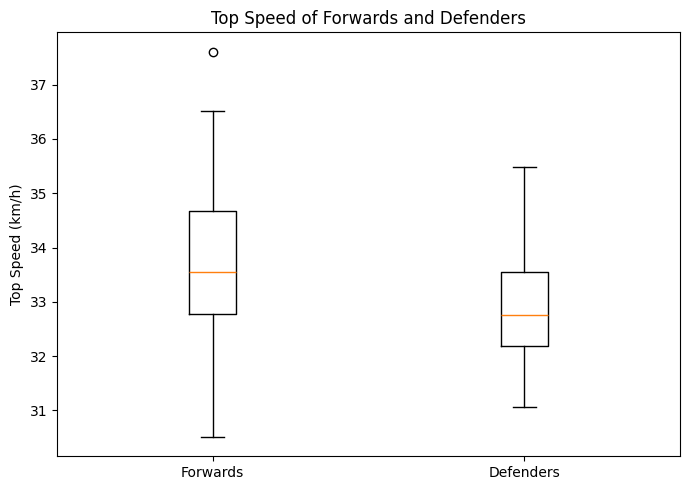

In [8]:
forward_speed = forwards_sample[
    "Top_Speed_kmh"
]

defender_speed = defenders_sample[
    "Top_Speed_kmh"
]

plt.figure(
    figsize=(7, 5)
)

plt.boxplot(
    [
        forward_speed,
        defender_speed
    ],
    tick_labels=[
        "Forwards",
        "Defenders"
    ]
)

plt.title(
    "Top Speed of Forwards and Defenders"
)

plt.ylabel(
    "Top Speed (km/h)"
)

plt.tight_layout()
plt.show()

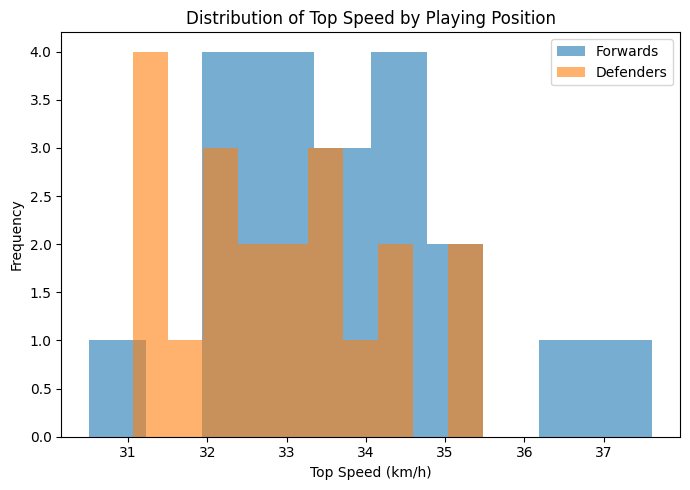

In [9]:
plt.figure(
    figsize=(7, 5)
)

plt.hist(
    forward_speed,
    alpha=0.6,
    label="Forwards"
)

plt.hist(
    defender_speed,
    alpha=0.6,
    label="Defenders"
)

plt.xlabel(
    "Top Speed (km/h)"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Distribution of Top Speed by Playing Position"
)

plt.legend()

plt.tight_layout()
plt.show()

In [10]:
def confidence_interval(values):

    n = len(values)

    mean = values.mean()

    standard_error = stats.sem(values)

    margin = stats.t.ppf(
        0.975,
        df=n - 1
    ) * standard_error

    lower = mean - margin
    upper = mean + margin

    return mean, lower, upper


fw_mean, fw_lower, fw_upper = confidence_interval(
    forward_speed
)

df_mean, df_lower, df_upper = confidence_interval(
    defender_speed
)


print(
    "Forwards mean:",
    round(fw_mean, 2)
)

print(
    "Forwards 95% CI:",
    round(fw_lower, 2),
    "to",
    round(fw_upper, 2)
)


print(
    "\nDefenders mean:",
    round(df_mean, 2)
)

print(
    "Defenders 95% CI:",
    round(df_lower, 2),
    "to",
    round(df_upper, 2)
)

Forwards mean: 33.76
Forwards 95% CI: 33.01 to 34.52

Defenders mean: 32.91
Defenders 95% CI: 32.31 to 33.52


In [11]:
fw_shapiro = stats.shapiro(
    forward_speed
)

df_shapiro = stats.shapiro(
    defender_speed
)


print(
    "Forwards Shapiro-Wilk p-value:",
    round(fw_shapiro.pvalue, 4)
)

print(
    "Defenders Shapiro-Wilk p-value:",
    round(df_shapiro.pvalue, 4)
)

Forwards Shapiro-Wilk p-value: 0.6976
Defenders Shapiro-Wilk p-value: 0.4457


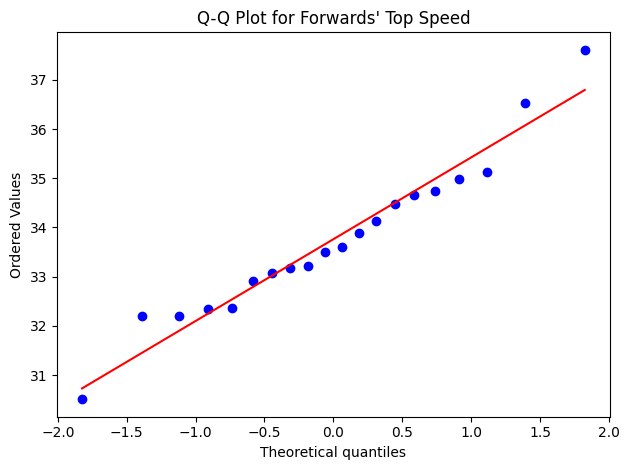

In [12]:
stats.probplot(
    forward_speed,
    dist="norm",
    plot=plt
)

plt.title(
    "Q-Q Plot for Forwards' Top Speed"
)

plt.tight_layout()
plt.show()


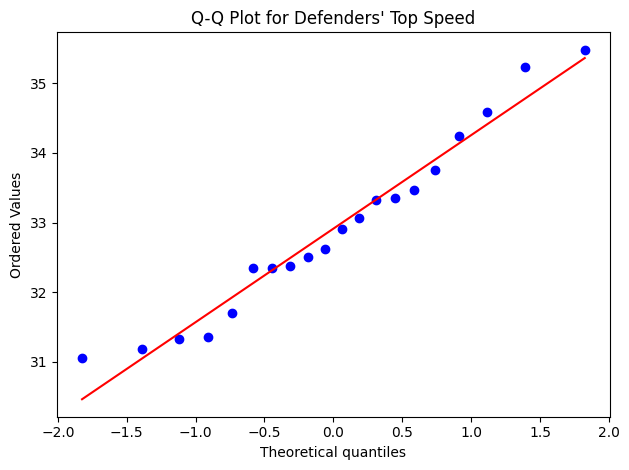

In [13]:
stats.probplot(
    defender_speed,
    dist="norm",
    plot=plt
)

plt.title(
    "Q-Q Plot for Defenders' Top Speed"
)

plt.tight_layout()
plt.show()

In [14]:
t_statistic, p_value = stats.ttest_ind(
    forward_speed,
    defender_speed,
    equal_var=False
)

print(
    "t-statistic:",
    round(t_statistic, 4)
)

print(
    "p-value:",
    round(p_value, 4)
)

t-statistic: 1.8362
p-value: 0.0745


In [15]:
alpha = 0.05

if p_value < alpha:

    print(
        "Reject the null hypothesis."
    )

    print(
        "There is statistically significant evidence "
        "of a difference in mean top speed between "
        "forwards and defenders."
    )

else:

    print(
        "Fail to reject the null hypothesis."
    )

    print(
        "There is insufficient statistical evidence "
        "of a difference in mean top speed between "
        "forwards and defenders."
    )

Fail to reject the null hypothesis.
There is insufficient statistical evidence of a difference in mean top speed between forwards and defenders.


In [16]:
mean_difference = (
    forward_speed.mean()
    - defender_speed.mean()
)

se_difference = np.sqrt(
    forward_speed.var(ddof=1) / len(forward_speed)
    +
    defender_speed.var(ddof=1) / len(defender_speed)
)

numerator = (
    forward_speed.var(ddof=1) / len(forward_speed)
    +
    defender_speed.var(ddof=1) / len(defender_speed)
) ** 2

denominator = (
    (
        forward_speed.var(ddof=1)
        / len(forward_speed)
    ) ** 2
    / (len(forward_speed) - 1)
    +
    (
        defender_speed.var(ddof=1)
        / len(defender_speed)
    ) ** 2
    / (len(defender_speed) - 1)
)

welch_df = numerator / denominator

t_critical = stats.t.ppf(
    0.975,
    df=welch_df
)

lower_difference = (
    mean_difference
    - t_critical * se_difference
)

upper_difference = (
    mean_difference
    + t_critical * se_difference
)

print(
    "Mean difference:",
    round(mean_difference, 2),
    "km/h"
)

print(
    "95% CI for mean difference:",
    round(lower_difference, 2),
    "to",
    round(upper_difference, 2),
    "km/h"
)

Mean difference: 0.85 km/h
95% CI for mean difference: -0.09 to 1.79 km/h
